In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

In [9]:
df = pd.read_parquet("../data/processed/pdb_protein_features_clean.parquet")

In [10]:
df

,pdb_id,organism,taxonomy_id,sequence,bfactor,bfactor_norm,length
0,6s2m,Homo sapiens,9606,GMSNKFLGTWKLVSSENFDDYMKALGVGLATRKLGNLAKPTVIISK...,"[25.25, 14.04, 11.68, 9.94, 9.32, 8.01, 8.01, ...","[2.8055556, 1.56, 1.2977778, 1.1044444, 1.0355...",133
1,8c5n,Pseudomonas aeruginosa PA14,652611,HGSMETPPSRVYGCFLEGPENPKSAACKAAVAAGGTQALYDWNGVN...,"[6.75, 6.26, 5.58, 5.94, 6.3, 6.59, 7.2, 6.74,...","[0.9782609, 0.9072464, 0.8086956, 0.8608696, 0...",193
2,2ov0,Paracoccus denitrificans,266,DKATIPSESPFAAAEVADGAIVVDIAKMKYETPELHVKVGDTVTWI...,"[12.38, 7.23, 7.56, 7.49, 5.76, 7.96, 5.56, 6....","[3.095, 1.8075, 1.89, 1.8725, 1.44, 1.99, 1.39...",105
3,7kr0,Severe acute respiratory syndrome coronavirus 2,2697049,SNAGEVNSFSGYLKLTDNVYIKNADIVEEAKKVKPTVVVNAANVYL...,"[nan, nan, nan, nan, 24.04, 15.98, 8.12, 8.86,...","[nan, nan, nan, nan, 2.8345716, 1.8842118, 0.9...",173
4,1x6z,Pseudomonas aeruginosa,287,ALEGTEFARSEGASALASVNPLKTTVEEALSRGWSVKSGTGTEDAT...,"[nan, nan, nan, 21.16, 12.6, 12.49, 10.39, 10....","[nan, nan, nan, 3.1117647, 1.8529412, 1.836764...",123
...,...,...,...,...,...,...,...
45787,3lj5,Enterobacteria phage P22,10754,MADNENRLESILSRFDADWTASDEARREAKNDLFFSRVSQWDDWLS...,"[nan, nan, nan, nan, 365.85, 395.28, 242.63, 2...","[nan, nan, nan, nan, 1.5462806, 1.6706678, 1.0...",725
45788,4whv,Homo sapiens,9606,GPLGSPEFMAGLPRRIIKETQRLLAEPVPGIKAEPDESNARYFHVV...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",160
45789,3w03,Homo sapiens,9606,SGMEELEQGLLMQPWAWLQLAENSLLAKVFITKQGYALLVSDLQQV...,"[36.06, 46.64, 45.49, 42.78, 41.46, 44.24, 43....","[0.038910173, 0.05032641, 0.049085516, 0.04616...",235
45790,8aj8,Sus scrofa,9823,MELENYEQPVVLREDNRRRRRRMKPRSTAASLSSMELIPIEFVLPT...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",1102


In [12]:
df.shape

(45792, 7)

In [23]:
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
sequence_data = df["sequence"].dropna().astype(str)
counts = {aa: 0 for aa in amino_acids}
for seq in sequence_data:
    for aa in seq:
        if aa in counts:
            counts[aa] += 1
        else:
            counts.setdefault(aa, 0)
            counts[aa] += 1

print("Amino acid counts:")
for aa in sorted(counts):
    print(f"{aa}: {counts[aa]}")

Amino acid counts:
A: 1116611
B: 14
C: 189649
D: 789342
E: 898946
F: 557782
G: 1035851
H: 372242
I: 758612
K: 800397
L: 1266005
M: 282411
N: 588790
P: 655979
Q: 527258
R: 686779
S: 911205
T: 790716
U: 19
V: 977656
W: 200486
X: 48310
Y: 497347
Z: 24


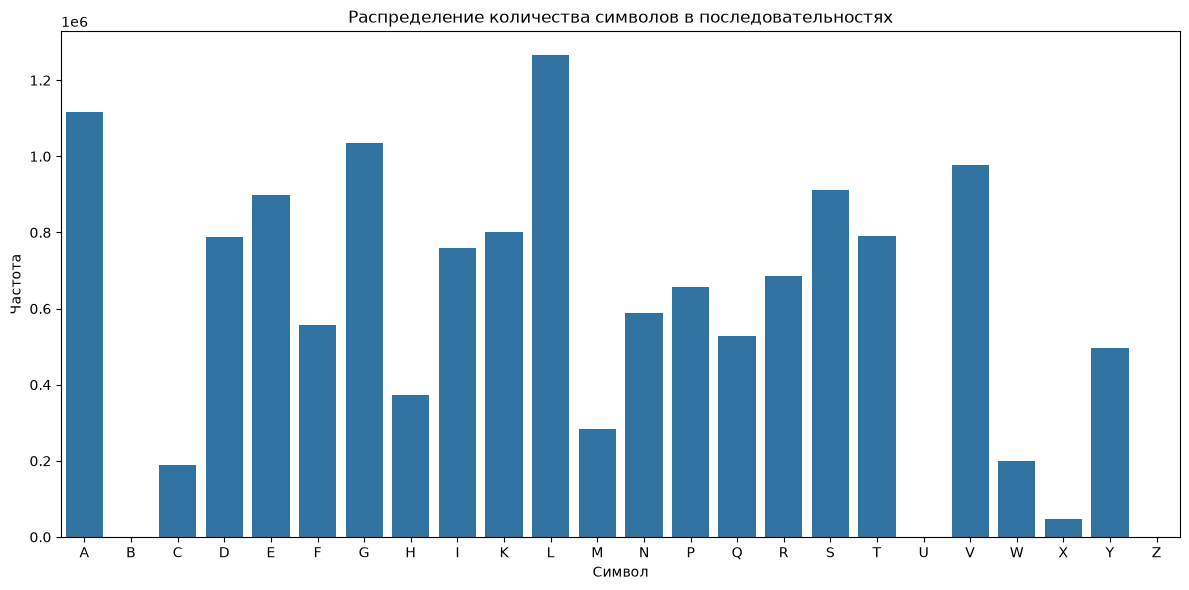

In [25]:
counts_series = pd.Series(counts).sort_index()
plt.figure(figsize=(12, 6))
sns.barplot(x=counts_series.index, y=counts_series.values)
plt.title("Распределение количества символов в последовательностях")
plt.xlabel("Символ")
plt.ylabel("Частота")
plt.tight_layout()

In [27]:
# use numpy RNG and vectorized normalization
rng = np.random.default_rng()
keys = list(counts.keys())
vals = np.array([counts[k] for k in keys], dtype=float)
counts_normalized = dict(zip(keys, vals / vals.sum()))

# infinite generator of uniform [0,1] using numpy
uniform_generator = (rng.random() for _ in iter(int, 1))

Text(0, 0.5, 'count')

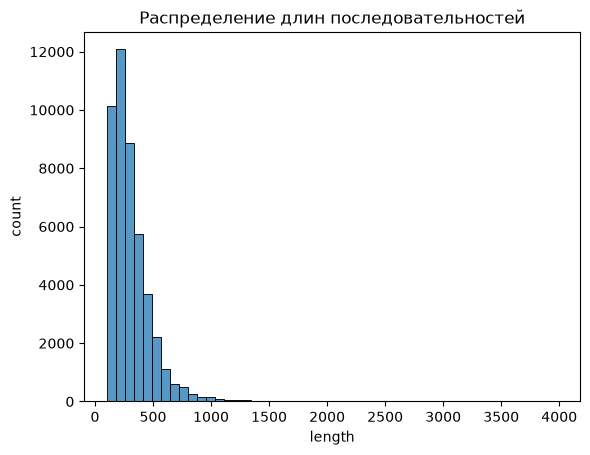

In [24]:
sns.histplot(lengths.dropna(), bins=50, kde=False)
plt.title("Распределение длин последовательностей")
plt.xlabel("length")
plt.ylabel("count")

Text(0, 0.5, 'density')

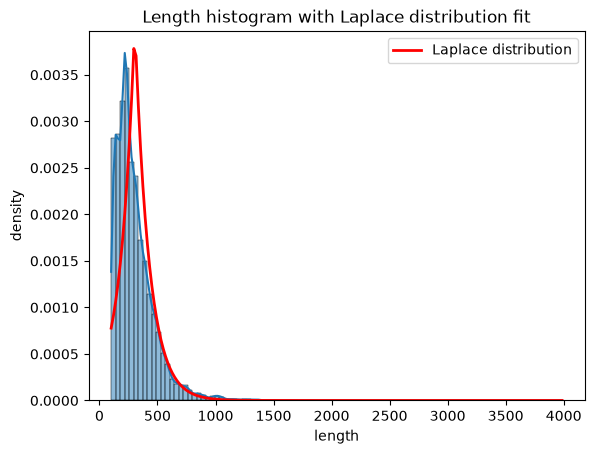

In [22]:
lengths = df["length"]
mean = lengths.mean()
std = lengths.std()
b = std / np.sqrt(2)
x = np.linspace(lengths.min(), lengths.max(), 200)
laplace_pdf = 1 / (2 * b) * np.exp(-np.abs(x - mean) / b)

sns.histplot(lengths, bins=100, stat="density", kde=True)
plt.plot(x, laplace_pdf, color="red", linewidth=2, label="Laplace distribution")
plt.legend()
plt.title("Length histogram with Laplace distribution fit")
plt.xlabel("length")
plt.ylabel("density")

In [ ]:
print(mean, std)

304.69145265548565 174.54222024084137


Best fits by AIC:
lognorm: AIC=576797.1, params=(np.float64(0.6611846581578649), 58.59298896417253, np.float64(198.88548935028427))
expon: AIC=578504.1, params=(101.0, 203.69145265548565)
laplace: AIC=593148.1, params=(np.float64(262.0), np.float64(119.50482617051013))


Text(0, 0.5, 'density')

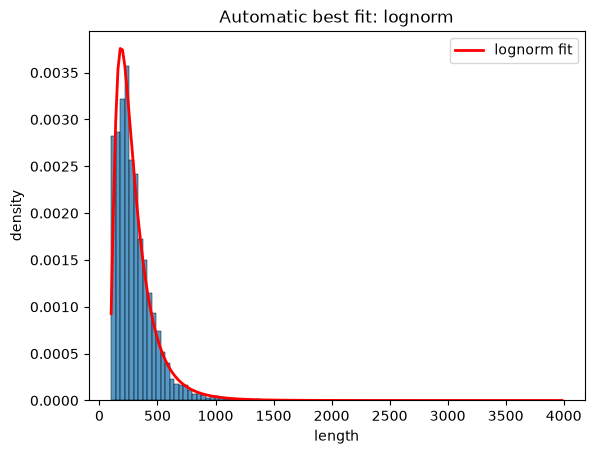

In [20]:
lengths = df["length"].dropna()

candidates = [st.norm, st.laplace, st.expon, st.gamma, st.lognorm]
fit_results = []
for dist in candidates:
    try:
        params = dist.fit(lengths)
        loglik = np.sum(dist.logpdf(lengths, *params))
        k = len(params)
        aic = 2 * k - 2 * loglik
        fit_results.append((dist.name, aic, params))
    except Exception:
        pass

fit_results = sorted(fit_results, key=lambda x: x[1])
print("Best fits by AIC:")
for name, aic, params in fit_results[:3]:
    print(f"{name}: AIC={aic:.1f}, params={params}")

best_name, best_aic, best_params = fit_results[0]
best_dist = getattr(st, best_name)

x = np.linspace(lengths.min(), lengths.max(), 200)
pdf = best_dist.pdf(x, *best_params)

sns.histplot(lengths, bins=100, stat="density", kde=False)
plt.plot(x, pdf, color="red", linewidth=2, label=f"{best_name} fit")
plt.legend()
plt.title(f"Automatic best fit: {best_name}")
plt.xlabel("length")
plt.ylabel("density")

In [32]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)
# draw 100 lengths from the fitted lognormal (best_dist, best_params), then build sequences
try:
    lengths_drawn = best_dist.rvs(*best_params, size=100, random_state=rng)
except TypeError:
    # fallback if scipy doesn't accept Generator: use numpy lognormal with scipy params
    s, loc, scale = best_params
    lengths_drawn = loc + rng.lognormal(mean=np.log(scale), sigma=float(s), size=100)

lengths_int = np.maximum(1, np.round(lengths_drawn).astype(int))

# prepare cumulative distribution from counts_normalized using existing keys order
prob_arr = np.array([counts_normalized[k] for k in keys], dtype=float)
prob_arr /= prob_arr.sum()
cdf = np.cumsum(prob_arr)

simulated_sequences = []
for L in lengths_int:
    seq_chars = [keys[np.searchsorted(cdf, next(uniform_generator))] for _ in range(L)]
    simulated_sequences.append("".join(seq_chars))

# expose result as a pandas Series
simulated_sequences = pd.Series(simulated_sequences)
simulated_sequences

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   FQYPRSFDSKAGCPGGLRALERFADLSYYTSSVEGLDNLWSFKFCCQPPIKKGLGLYDDSIPYDIQAPVADTASIAGYRIVKEFTAKPILDGACVCLNNCVKAKYTISTIWPNMADFHYDDAILYKDITPYTVVEFVNATEWAANEGFQAVYQTLDLKEYVMGGGQVAGYDKFNGDKGLESPELATLMALQRASKVLYGLGMSFVLMAGXVRITLMSPSNYPDAEKNGSAVELFREECYYTGVTVPPSPATFLKEGRAFGTVRLLCELSQQPVTSSSMSAGDLPLFKASFQGAARRKKGKAYKGKASNYNSIDGDAKHEMTMLTTAVLTYVIWQSQFPRDAKVVPLEYAIMVRAILLYVRLIPFIESTAGSTFSHNTMLGISVIGILLVPLPDRNASMSYFLTECIGGVRSSNVIVAWVEIKVLIRYACNTSAEER